## data preparation

In [ ]:
# load required libraries
#!pip install shapely scikit-learn shap rasterio -q
import geopandas as gpd
import rasterio
import numpy as np
import pandas as pd
from rasterio.mask import mask
from shapely.geometry import Point
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.metrics import mean_squared_error, r2_score
import shap
import matplotlib.pyplot as plt

# mount drive
# from google.colab import drive
# drive.mount('/content/drive')

# load the biomass training points shapefile
biomass_gdf = gpd.read_file("/content/drive/MyDrive/GEE_Exports/Biomass_MTBS_ModHigh_Stratified_Sampled_toWeights.shp") # includes tree and shrub

# define raster paths for feature set
landsat_path = "/content/drive/MyDrive/biomass_research/L8_Composite_2023_mosaic.tif"
et_path = "/content/drive/MyDrive/biomass_research/ET_2023.tif"
terrain_path = "/content/drive/MyDrive/GEE_Exports/terrain_30m.tif"
chm_path = '/content/drive/MyDrive/biomass_research/reprojected_CHM.tif'
soil_path = '/content/drive/MyDrive/biomass_research/soils_mosaic.tif'

In [ ]:
# our first task is to create a gdf that assigns feature values to each biomass point so we can train/test our model
def extract_raster_values(raster_path, gdf, band_names=None):
    """extracts raster values at point locations and adds them to the geodataframe, avoiding duplicate columns."""
    with rasterio.open(raster_path) as src:
        coords = [(x, y) for x, y in zip(gdf.geometry.x, gdf.geometry.y)]
        values = np.array([v for v in src.sample(coords)])

        # handle NoData (255.0 for CHM) - replace with NaN
        nodata = src.nodata
        if nodata is not None:
            values = np.where(values == nodata, np.nan, values)

        if band_names is None:
            band_names = [f'band_{i+1}' for i in range(values.shape[1])]

        df = pd.DataFrame(values, columns=band_names)

        # drop existing columns to prevent duplicates
        gdf = gdf.drop(columns=[col for col in band_names if col in gdf.columns], errors="ignore")

        return pd.concat([gdf.reset_index(drop=True), df], axis=1)


# make sure both datasets are in same crs
target_crs = "EPSG:32614"  # UTM Zone 14N

# ensure crs is correct before extraction
biomass_gdf = biomass_gdf.to_crs(target_crs)

# extract values from feature rasters and name the bands for clarity
biomass_gdf = extract_raster_values(landsat_path, biomass_gdf,
                                    band_names=['Blue', 'Green', 'Red', 'NIR', 'SWIR1', 'SWIR2', 'NDVI', 'EVI','SAVI', 'MSAVI', 'NDMI'])
biomass_gdf = extract_raster_values(et_path, biomass_gdf, band_names=['ET'])
biomass_gdf = extract_raster_values(terrain_path, biomass_gdf, band_names=['DEM', 'Slope', 'Aspect'])
biomass_gdf = extract_raster_values(soil_path, biomass_gdf, band_names=['bd','clay', 'ksat', 'n', 'om', 'ph', 'sand', 'silt', 'theta_r', 'theta_s', 'lambda', 'hb', 'alpha'])

with rasterio.open(chm_path) as src:
    chm_array = src.read(1)
    print("CHM dtype:", chm_array.dtype)
    print("CHM min/max:", chm_array.min(), chm_array.max())

biomass_gdf = extract_raster_values(chm_path, biomass_gdf, band_names=['CHM'])

# check if extraction worked
print("First few extracted values:\n", biomass_gdf[['Blue', 'Green', 'Red', 'NIR', 'SWIR1', 'ET', 'DEM', 'Slope', 'Aspect', 'CHM', 'om', 'sand']].head())

# # save to csv for later use
biomass_gdf.to_csv("/content/drive/MyDrive/biomass_research/total_biomass_gdf_extracted_mtbs_toweights", index=False)

CHM dtype: float32
CHM min/max: 0.0 255.0
First few extracted values:
        Blue     Green       Red       NIR     SWIR1     ET         DEM  Slope  \
0  0.258954  0.286633  0.303806  0.448772  0.491755  823.0  648.614746    3.0   
1  0.265898  0.304013  0.314490  0.451110  0.498933  810.0  329.930054    6.0   
2  0.264000  0.305607  0.329753  0.472945  0.501215  838.0  726.593384    3.0   
3  0.294635  0.330729  0.367593  0.457545  0.607172  287.0  680.693726   16.0   
4  0.275619  0.300960  0.321255  0.425081  0.524920  229.0  735.413879    0.0   

   Aspect  CHM        om       sand  
0   334.0  6.0  0.250308  15.354351  
1   188.0  6.0  0.387507  26.500000  
2   302.0  6.0  0.651170  40.067650  
3    58.0  7.0  0.615381  40.067650  
4    71.0  5.0  0.522671  40.067650  


In [ ]:
#biomass_gdf = pd.read_csv("/content/drive/MyDrive/biomass_research/total_biomass_gdf_extracted_mtbs_toweights")

# now to combine shrub and tree into one column to predict woody biomass
biomass_gdf['total_biomass'] = biomass_gdf['treeBiomas'] + biomass_gdf['shrubBioma']

biomass_gdf['total_biomass'].describe()

,total_biomass
count,4800.000000
mean,9365.810260
std,9620.555868
min,0.000000
25%,2398.657973
50%,6703.509935
75%,12764.336665
max,101422.225500


In [ ]:
biomass_gdf.head()

,dNBR_max,latitude,yearsSince,shrubBioma,treeBiomas,longitude,severity_m,geometry,Blue,Green,...,ph,sand,silt,theta_r,theta_s,lambda,hb,alpha,CHM,total_biomass
0,0.657406,32.312401,1,180.304336,0.000000,-99.931583,3.0,POINT (412305 3575445),0.258954,0.286633,...,7.994457,15.354351,52.253181,0.084369,0.487630,0.260436,0.672144,-0.673894,6.0,180.304336
1,0.437298,29.492689,1,401.731048,318.971008,-98.936297,3.0,POINT (506175 3262575),0.265898,0.304013,...,6.963500,26.500000,37.250000,0.079538,0.535849,0.321695,-0.039355,0.043113,6.0,720.702056
2,0.331092,32.300141,1,237.415176,54.541325,-99.905648,3.0,POINT (414735 3574065),0.264000,0.305607,...,7.766644,40.067650,45.318714,0.063308,0.507025,0.318776,0.314180,-0.322522,6.0,291.956501
3,0.744896,32.308813,1,0.000000,0.000000,-99.941106,4.0,POINT (411405 3575055),0.294635,0.330729,...,7.861848,40.067650,45.012672,0.063308,0.507025,0.318776,0.314180,-0.322522,7.0,0.000000
4,0.439707,30.685254,1,342.865783,456.343811,-100.247575,3.0,POINT (380505 3395385),0.275619,0.300960,...,7.763228,40.067650,43.533234,0.063308,0.507025,0.318776,0.314180,-0.322522,5.0,799.209594


## model set up

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_sample_weight

# drop rows with missing values (due to extraction issues)
print("Before dropna:", len(biomass_gdf))
print("Missing values by column:\n", biomass_gdf.isna().sum())
biomass_gdf = biomass_gdf.dropna()
print("After dropna:", len(biomass_gdf))

Before dropna: 4800
Missing values by column:
 dNBR_max         0
latitude         0
yearsSince       0
shrubBioma       0
treeBiomas       0
longitude        0
severity_m       0
geometry         0
Blue             0
Green            0
Red              0
NIR              0
SWIR1            0
SWIR2            0
NDVI             0
EVI              0
SAVI             0
MSAVI            0
NDMI             0
ET               0
DEM              0
Slope            0
Aspect           0
bd               0
clay             0
ksat             0
n                0
om               0
ph               0
sand             0
silt             0
theta_r          0
theta_s          0
lambda           0
hb               0
alpha            0
CHM              0
total_biomass    0
dtype: int64
After dropna: 4800


In [ ]:
# load libraries
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import shap
import numpy as np

# drop non-numeric columns and target variables
# define features
X = biomass_gdf.drop(columns=["treeBiomas", "shrubBioma", "total_biomass", "geometry", "NDVI"]) # we'll drop NDVI so we avoid any circularity with the NPP data (since it's Landsat NDVI-derived)

# keep only numeric columns
X = X.select_dtypes(include=np.number)
y = biomass_gdf["total_biomass"]  # specify the tree band as our target variable

# ============================================
# COMPUTE SAMPLE WEIGHTS BASED ON SEVERITY
# ============================================
severity_class = biomass_gdf['severity_m']  # or 'severity_max' - check your column name

# Compute inverse frequency weights
sample_weights = compute_sample_weight(
    class_weight='balanced',
    y=severity_class
)

print("\nSample weight statistics:")
print(f"  Moderate (3) - count: {(severity_class==3).sum()}, mean weight: {sample_weights[severity_class==3].mean():.3f}")
print(f"  High (4) - count: {(severity_class==4).sum()}, mean weight: {sample_weights[severity_class==4].mean():.3f}")
print(f"  Weight ratio (High/Moderate): {sample_weights[severity_class==4].mean() / sample_weights[severity_class==3].mean():.2f}x")

# split dataset into 80% training and 20% testing
# MODIFIED: Also split the sample weights
X_train, X_test, y_train, y_test, w_train, w_test = train_test_split(
    X, y, sample_weights,
    test_size=0.2,
    random_state=42
)


Sample weight statistics:
  Moderate (3) - count: 4590, mean weight: 0.523
  High (4) - count: 210, mean weight: 11.429
  Weight ratio (High/Moderate): 21.86x


In [ ]:
# preview
X_train.head()

,dNBR_max,latitude,yearsSince,longitude,severity_m,Blue,Green,Red,NIR,SWIR1,...,om,ph,sand,silt,theta_r,theta_s,lambda,hb,alpha,CHM
2758,0.438047,31.683596,15,-101.150318,3.0,0.280858,0.317570,0.344602,0.480150,0.536497,...,0.299697,7.778472,7.756109,54.614483,0.091131,0.510962,0.246696,0.612230,-0.609080,3.0
2850,0.195959,31.540219,15,-101.211790,3.0,0.261731,0.287017,0.304837,0.393841,0.448649,...,0.275840,8.053077,19.769981,41.088638,0.099729,0.515450,0.257588,0.574373,-0.570751,3.0
4440,0.034568,31.147374,20,-99.018307,3.0,0.259820,0.288832,0.306515,0.454437,0.521372,...,0.313643,5.848000,46.500000,33.500000,0.049186,0.505660,0.412509,-0.097095,0.098008,5.0
4576,0.104201,30.632022,22,-100.423116,3.0,0.273322,0.306405,0.329890,0.430870,0.518430,...,0.327987,7.885867,40.067650,37.071846,0.063308,0.507025,0.318776,0.314180,-0.322522,4.0
1774,0.026097,30.832004,8,-99.047735,3.0,0.242000,0.268207,0.277887,0.411730,0.446435,...,-0.133363,6.436854,43.459961,22.798244,0.056681,0.475685,0.335611,0.234690,-0.234478,6.0


## random forest implementation

In [ ]:
# load libraries
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import shap
import numpy as np

# define RF model from sklearn
rf = RandomForestRegressor(random_state=42)

# define hyperparameter distributions
param_dist = {
    'n_estimators': [200, 500, 1000, 1500, 2000],       # preliminary runs identified 1,000 as ideal so we will test around that value
    'max_depth': [None] + list(np.arange(10, 101, 10)),  # None or 10–100
    'min_samples_split': np.arange(2, 21, 2),        # 2–20
    'min_samples_leaf': np.arange(1, 11, 1),         # 1–10
    'max_features': ['sqrt', 'log2', None, 0.3, 0.5]         # common feature selection options
}

# perform Randomized Search with 5-fold cross validation
# MODIFIED: Added fit_params to pass sample weights
random_search = RandomizedSearchCV(
    rf,
    param_distributions=param_dist,
    n_iter=50,
    cv=5,
    scoring='r2',
    verbose=2,
    n_jobs=-1,
    random_state=42
)

# MODIFIED: Pass sample weights during fitting
random_search.fit(X_train, y_train, sample_weight=w_train)

# get best model
best_rf = random_search.best_estimator_

# make predictions
y_pred = best_rf.predict(X_test)

# evaluate model
r2 = r2_score(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5

print(f"Best Parameters: {random_search.best_params_}")
print(f"Test R² Score: {r2:.4f}")
print(f"Test RMSE: {rmse:.4f}")

# evaluate by severity class
severity_test = severity_class.iloc[X_test.index]

for sev in [3, 4]:
    mask = severity_test == sev
    sev_name = "Moderate" if sev == 3 else "High"

    if mask.sum() > 0:
        r2_sev = r2_score(y_test[mask], y_pred[mask])
        rmse_sev = mean_squared_error(y_test[mask], y_pred[mask]) ** 0.5

        print(f"\n{sev_name} Severity (n={mask.sum()}):")
        print(f"  R²: {r2_sev:.4f}")
        print(f"  RMSE: {rmse_sev:.4f}")


Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best Parameters: {'n_estimators': 1500, 'min_samples_split': np.int64(10), 'min_samples_leaf': np.int64(1), 'max_features': None, 'max_depth': np.int64(60)}
Test R² Score: 0.7829
Test RMSE: 4653.2948

Moderate Severity (n=911):
  R²: 0.7801
  RMSE: 4494.0538

High Severity (n=49):
  R²: 0.7936
  RMSE: 6981.0198


In [ ]:
# save the rf model to drive for later reference
import joblib

joblib.dump(best_rf, '/content/drive/MyDrive/biomass_research/best_rf_model_weighted_mtbs.pkl')

['/content/drive/MyDrive/biomass_research/best_rf_model_weighted_mtbs.pkl']

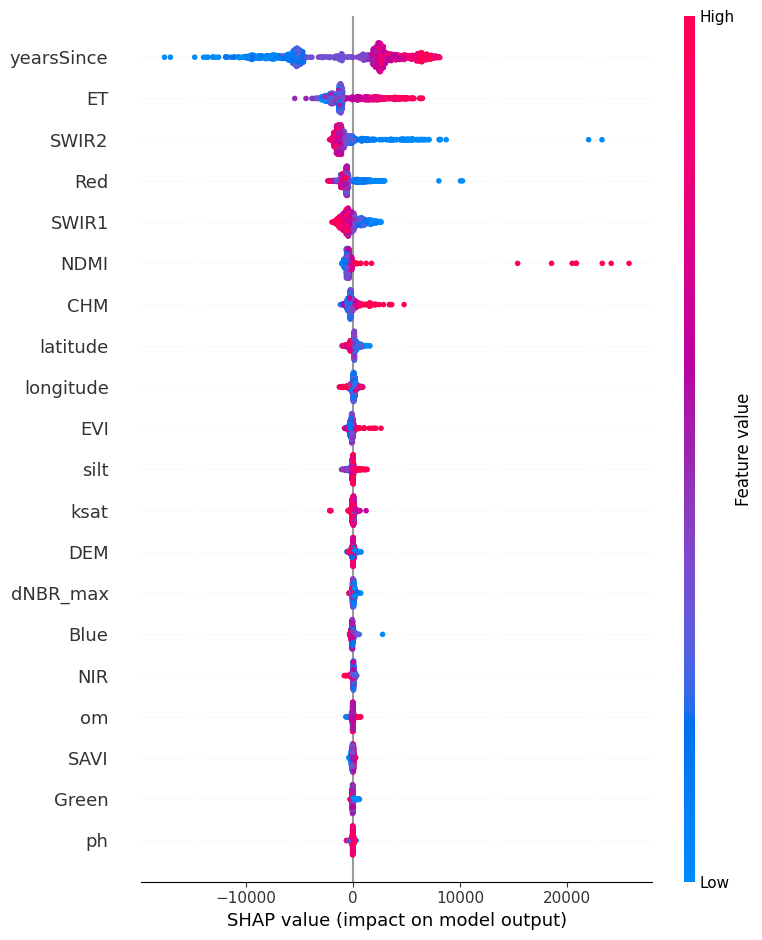

In [ ]:
# run shap to get feature importance values
explainer = shap.TreeExplainer(best_rf)
shap_values = explainer.shap_values(X_test)

# plot results
shap.summary_plot(shap_values, X_test, feature_names=X_test.columns)

## apply model to whole raster stack

In [ ]:
import os
import joblib
import numpy as np
import pandas as pd
import rasterio
from rasterio.windows import Window
from rasterio.warp import Resampling
from tqdm import tqdm

## ----------- set up parameters ------------
output_dir = "/content/drive/MyDrive/biomass_research/biomass_tiles_rf_masked_mtbs_weighted"
os.makedirs(output_dir, exist_ok=True)

model = joblib.load("/content/drive/MyDrive/biomass_research/best_rf_model_weighted_mtbs.pkl")

final_output = "/content/drive/MyDrive/biomass_research/biomass_tiles_rf_masked_mtbs_weighted.tif"
tile_size = 256

# define rasters - NOTE: Landsat has 11 bands but we'll skip NDVI (index 6)
rasters = {
    "landsat": ("/content/drive/MyDrive/biomass_research/L8_Composite_2023_mosaic.tif",
                ['Blue', 'Green', 'Red', 'NIR', 'SWIR1', 'SWIR2', 'NDVI', 'EVI', 'SAVI', 'MSAVI', 'NDMI']),
    "et": ("/content/drive/MyDrive/biomass_research/ET_2023.tif",
           ['ET']),
    "terrain": ("/content/drive/MyDrive/GEE_Exports/terrain_30m.tif",
                ['DEM', 'Slope', 'Aspect']),
    "soil": ("/content/drive/MyDrive/biomass_research/soils_mosaic.tif",
             ['bd', 'clay', 'ksat', 'n', 'om', 'ph', 'sand', 'silt', 'theta_r', 'theta_s', 'lambda', 'hb', 'alpha']),
    "chm": ("/content/drive/MyDrive/biomass_research/reprojected_CHM_aligned.tif",
            ['CHM']),
    "dnbr": ("/content/drive/MyDrive/biomass_research/dNBR_max_filled.tif",
             ['dNBR_max']),
    "latitude": ("/content/drive/MyDrive/biomass_research/latitude.tif",
                 ['latitude']),
    "yearssince": ("/content/drive/MyDrive/biomass_research/yearsSince_filled.tif",
                   ['yearsSince']),
    "longitude": ("/content/drive/MyDrive/biomass_research/longitude.tif",
                  ['longitude']),
    "severity": ("/content/drive/MyDrive/biomass_research/severity_m_filled.tif",
                 ['severity_m']),
}

# this must match the order from training
feature_names_training_order = ['dNBR_max', 'latitude', 'yearsSince', 'longitude', 'severity_m', 'Blue', 'Green', 'Red', 'NIR',
'SWIR1', 'SWIR2', 'EVI', 'SAVI', 'MSAVI', 'NDMI', 'ET', 'DEM', 'Slope', 'Aspect', 'bd', 'clay', 'ksat', 'n', 'om', 'ph', 'sand',
 'silt', 'theta_r', 'theta_s', 'lambda', 'hb', 'alpha', 'CHM']

print(f"Feature order: {feature_names_training_order}")
print(f"Total features: {len(feature_names_training_order)}")
print(f"Model expects: {model.n_features_in_} features")

# verify feature count matches
assert len(feature_names_training_order) == model.n_features_in_, \
    f"Feature mismatch! Model expects {model.n_features_in_}, but got {len(feature_names_training_order)}"

# get raster dimensions from reference raster
with rasterio.open(rasters["landsat"][0]) as ref:
    width, height = ref.width, ref.height
    ref_transform = ref.transform
    profile = ref.profile
    profile.update(dtype=rasterio.float32, count=1)

total_tiles = ((height + tile_size - 1) // tile_size) * ((width + tile_size - 1) // tile_size)
tile_count = 0

# load NLCD land cover mask from GEE during training data collection just to make sure we're not extrapolating
forest_mask_path = '/content/drive/MyDrive/GEE_Exports/forestMask_32614.tif'

Feature order: ['dNBR_max', 'latitude', 'yearsSince', 'longitude', 'severity_m', 'Blue', 'Green', 'Red', 'NIR', 'SWIR1', 'SWIR2', 'EVI', 'SAVI', 'MSAVI', 'NDMI', 'ET', 'DEM', 'Slope', 'Aspect', 'bd', 'clay', 'ksat', 'n', 'om', 'ph', 'sand', 'silt', 'theta_r', 'theta_s', 'lambda', 'hb', 'alpha', 'CHM']
Total features: 33
Model expects: 33 features


In [ ]:
## IMPROVED MODEL PREDS AND STD DEV COMPUTATION TEST --------------------------------------------------------------------

import warnings
warnings.filterwarnings("ignore", message="X has feature names, but DecisionTreeRegressor was fitted without feature names")

## ----------- set up parameters for BOTH outputs ------------
output_dir_pred = "/content/drive/MyDrive/biomass_research/biomass_tiles_rf_predictions_weighted"
output_dir_std = "/content/drive/MyDrive/biomass_research/biomass_tiles_rf_stddev_weighted"
os.makedirs(output_dir_pred, exist_ok=True)
os.makedirs(output_dir_std, exist_ok=True)

final_output_pred = "/content/drive/MyDrive/biomass_research/biomass_predictions_masked_mtbs_weighted.tif"
final_output_std = "/content/drive/MyDrive/biomass_research/biomass_stddev_masked_mtbs_weighted.tif"

tile_size = 256

# define rasters (skipping NDVI)
rasters = {
    "landsat": ("/content/drive/MyDrive/biomass_research/L8_Composite_2023_mosaic.tif",
                ['Blue', 'Green', 'Red', 'NIR', 'SWIR1', 'SWIR2', 'NDVI', 'EVI', 'SAVI', 'MSAVI', 'NDMI']),
    "et": ("/content/drive/MyDrive/biomass_research/ET_2023.tif",
           ['ET']),
    "terrain": ("/content/drive/MyDrive/GEE_Exports/terrain_30m.tif",
                ['DEM', 'Slope', 'Aspect']),
    "soil": ("/content/drive/MyDrive/biomass_research/soils_mosaic.tif",
             ['bd', 'clay', 'ksat', 'n', 'om', 'ph', 'sand', 'silt', 'theta_r', 'theta_s', 'lambda', 'hb', 'alpha']),
    "chm": ("/content/drive/MyDrive/biomass_research/reprojected_CHM_aligned.tif",
            ['CHM']),
    "dnbr": ("/content/drive/MyDrive/biomass_research/dNBR_max_filled.tif",
             ['dNBR_max']),
    "latitude": ("/content/drive/MyDrive/biomass_research/latitude.tif",
                 ['latitude']),
    "yearssince": ("/content/drive/MyDrive/biomass_research/yearsSince_filled.tif",
                   ['yearsSince']),
    "longitude": ("/content/drive/MyDrive/biomass_research/longitude.tif",
                  ['longitude']),
    "severity": ("/content/drive/MyDrive/biomass_research/severity_m_filled.tif",
                 ['severity_m']),
}

# training feature order
feature_names_training_order = [
    'dNBR_max', 'latitude', 'yearsSince', 'longitude', 'severity_m',
    'Blue', 'Green', 'Red', 'NIR', 'SWIR1', 'SWIR2', 'EVI', 'SAVI', 'MSAVI', 'NDMI',
    'ET', 'DEM', 'Slope', 'Aspect',
    'bd', 'clay', 'ksat', 'n', 'om', 'ph', 'sand', 'silt', 'theta_r', 'theta_s', 'lambda', 'hb', 'alpha',
    'CHM'
]

print(f"Feature order: {feature_names_training_order}")
print(f"Total features: {len(feature_names_training_order)}")
print(f"Model expects: {model.n_features_in_} features")

assert len(feature_names_training_order) == model.n_features_in_, \
    f"Feature mismatch! Model expects {model.n_features_in_}, but got {len(feature_names_training_order)}"

# forest mask
forest_mask_path = "/content/drive/MyDrive/GEE_Exports/forestMask_32614.tif"

# get reference raster shape/profile/transform
with rasterio.open(rasters["landsat"][0]) as ref:
    width, height = ref.width, ref.height
    ref_transform = ref.transform
    profile = ref.profile
    profile.update(dtype=rasterio.float32, count=1, compress='deflate')

total_tiles = ((height + tile_size - 1) // tile_size) * ((width + tile_size - 1) // tile_size)
tile_count = 0

print("Starting tile-based prediction AND standard deviation computation...")

## ------------- predict BOTH mean and stddev in one pass -------------
for y in tqdm(range(0, height, tile_size), desc="Rows"):
    for x in range(0, width, tile_size):
        tile_filename_pred = os.path.join(output_dir_pred, f"tile_{x}_{y}.tif")
        tile_filename_std = os.path.join(output_dir_std, f"tile_{x}_{y}.tif")

        window = Window(x, y, min(tile_size, width - x), min(tile_size, height - y))

        tile_data = {}
        valid = True

        # read data for current tile from all raster sources
        for key, (path, bands) in rasters.items():
            with rasterio.open(path) as src:
                try:
                    arr = src.read(window=window,
                                   out_shape=(src.count, window.height, window.width),
                                   resampling=Resampling.bilinear)
                    for i, band_name in enumerate(bands):
                        if band_name == 'NDVI':
                            continue  # SKIP NDVI
                        tile_data[band_name] = arr[i, :, :]
                except Exception as e:
                    print(f"Error reading {key}: {e}")
                    valid = False
                    break

        if not valid:
            print(f"Skipping tile x={x}, y={y} due to read error")
            tile_count += 1
            continue

        # read forest mask for current tile
        with rasterio.open(forest_mask_path) as mask_src:
            try:
                forest_mask_tile = mask_src.read(1, window=window,
                                                 out_shape=(window.height, window.width),
                                                 resampling=Resampling.nearest)
            except:
                print(f"Skipping tile x={x}, y={y} due to mask read error")
                tile_count += 1
                continue

        # stack features in the CORRECT ORDER
        stacked = np.array([tile_data[name] for name in feature_names_training_order])
        flat = stacked.reshape(stacked.shape[0], -1).T  # (pixels, features)

        # create combined mask
        valid_mask = ~np.isnan(flat).any(axis=1)
        forest_mask_flat = forest_mask_tile.flatten() == 1
        combined_mask = valid_mask & forest_mask_flat

        # prepare output containers for BOTH predictions and stddev
        preds_mean = np.full(flat.shape[0], np.nan, dtype=np.float32)
        preds_std = np.full(flat.shape[0], np.nan, dtype=np.float32)

        # make predictions only for valid forest pixels
        if combined_mask.any():
            flat_df = pd.DataFrame(flat[combined_mask], columns=feature_names_training_order)

            # Get predictions from all trees: shape (n_trees, n_pixels)
            tree_preds = np.array([tree.predict(flat_df) for tree in model.estimators_], dtype=np.float32)

            # Compute BOTH mean and stddev
            mean_preds = np.mean(tree_preds, axis=0)
            std_preds = np.std(tree_preds, axis=0)

            preds_mean[combined_mask] = mean_preds
            preds_std[combined_mask] = std_preds

        # reshape and save PREDICTIONS tile
        pred_tile_mean = preds_mean.reshape(window.height, window.width).astype(np.float32)
        tile_profile = profile.copy()
        tile_profile.update(
            height=window.height,
            width=window.width,
            transform=rasterio.windows.transform(window, ref_transform),
            tiled=True,
            blockxsize=256,
            blockysize=256
        )

        with rasterio.open(tile_filename_pred, 'w', **tile_profile) as dst:
            dst.write(pred_tile_mean, 1)

        # reshape and save STDDEV tile
        pred_tile_std = preds_std.reshape(window.height, window.width).astype(np.float32)

        with rasterio.open(tile_filename_std, 'w', **tile_profile) as dst:
            dst.write(pred_tile_std, 1)

        tile_count += 1

print(f"Finished processing {tile_count}/{total_tiles} tiles")
print(f"Prediction tiles saved to: {output_dir_pred}")
print(f"Stddev tiles saved to: {output_dir_std}")

## ------ mosaic PREDICTIONS tiles back together ----------
print("\nMosaicking prediction tiles...")
tile_files_pred = [os.path.join(output_dir_pred, f) for f in os.listdir(output_dir_pred) if f.endswith('.tif')]
tile_files_pred.sort()

with rasterio.open(final_output_pred, 'w', **profile) as dst:
    for tile_file in tqdm(tile_files_pred, desc="Mosaicking predictions"):
        with rasterio.open(tile_file) as src:
            tile_data = src.read(1)
            filename = os.path.basename(tile_file)
            x, y = map(int, filename.replace('tile_', '').replace('.tif', '').split('_'))
            window = Window(x, y, tile_data.shape[1], tile_data.shape[0])
            dst.write(tile_data, 1, window=window)

print(f"Final prediction mosaic saved to: {final_output_pred}")

## ------ mosaic STDDEV tiles back together ----------
print("\nMosaicking stddev tiles...")
tile_files_std = [os.path.join(output_dir_std, f) for f in os.listdir(output_dir_std) if f.endswith('.tif')]
tile_files_std.sort()

with rasterio.open(final_output_std, 'w', **profile) as dst:
    for tile_file in tqdm(tile_files_std, desc="Mosaicking stddev"):
        with rasterio.open(tile_file) as src:
            tile_data = src.read(1)
            filename = os.path.basename(tile_file)
            x, y = map(int, filename.replace('tile_', '').replace('.tif', '').split('_'))
            window = Window(x, y, tile_data.shape[1], tile_data.shape[0])
            dst.write(tile_data, 1, window=window)

print(f"Final stddev mosaic saved to: {final_output_std}")

# Clean up individual tiles
import shutil
shutil.rmtree(output_dir_pred)
shutil.rmtree(output_dir_std)
print("\nIndividual tiles cleaned up")
print("\n✓ Both outputs complete!")

Feature order: ['dNBR_max', 'latitude', 'yearsSince', 'longitude', 'severity_m', 'Blue', 'Green', 'Red', 'NIR', 'SWIR1', 'SWIR2', 'EVI', 'SAVI', 'MSAVI', 'NDMI', 'ET', 'DEM', 'Slope', 'Aspect', 'bd', 'clay', 'ksat', 'n', 'om', 'ph', 'sand', 'silt', 'theta_r', 'theta_s', 'lambda', 'hb', 'alpha', 'CHM']
Total features: 33
Model expects: 33 features
Starting tile-based prediction AND standard deviation computation...


Rows: 100%|██████████| 46/46 [4:51:50<00:00, 380.66s/it]


Finished processing 2484/2484 tiles
Prediction tiles saved to: /content/drive/MyDrive/biomass_research/biomass_tiles_rf_predictions_weighted
Stddev tiles saved to: /content/drive/MyDrive/biomass_research/biomass_tiles_rf_stddev_weighted

Mosaicking prediction tiles...


Mosaicking predictions: 100%|██████████| 2484/2484 [17:29<00:00,  2.37it/s]


Final prediction mosaic saved to: /content/drive/MyDrive/biomass_research/biomass_predictions_masked_mtbs_weighted.tif

Mosaicking stddev tiles...


Mosaicking stddev: 100%|██████████| 2484/2484 [16:04<00:00,  2.58it/s]


Final stddev mosaic saved to: /content/drive/MyDrive/biomass_research/biomass_stddev_masked_mtbs_weighted.tif

Individual tiles cleaned up

✓ Both outputs complete!


## calculate uncertainty from model

Class 1 pixels: 8377890, Class 2: 33240532, Class 3: 13248941


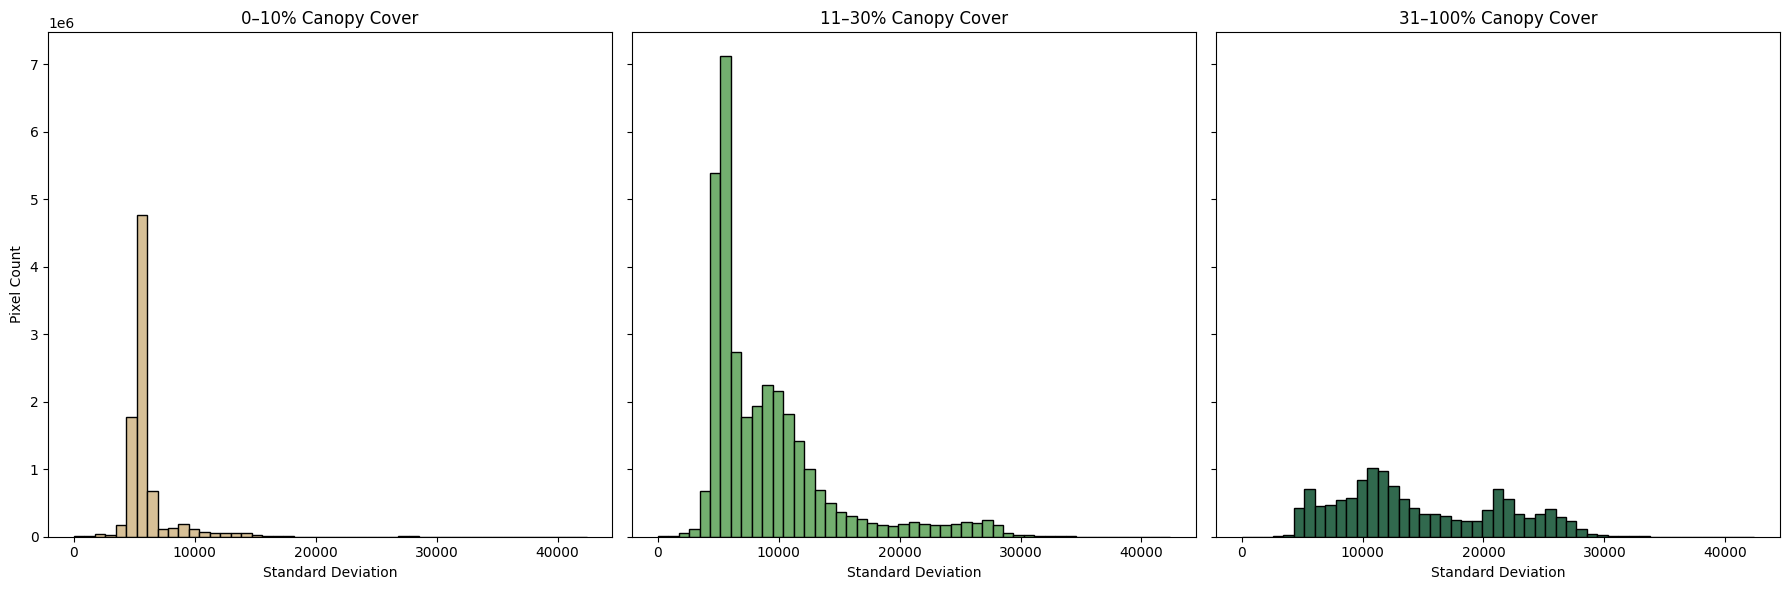

In [ ]:
 # load libraries
import rasterio
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
from rasterio.features import geometry_mask

# load std dev raster
with rasterio.open("/content/drive/MyDrive/biomass_research/biomass_stddev_masked_mtbs_weighted.tif") as src:
    data = src.read(1)
    transform = src.transform
    crs = src.crs

# load canopy cover class shapefiles and reproject to raster std dev CRS
class1_shp = gpd.read_file('/content/drive/MyDrive/GEE_Exports/canopy_class_1_0-10pct.shp').to_crs(crs)
class2_shp = gpd.read_file('/content/drive/MyDrive/GEE_Exports/canopy_class_2_11-30pct.shp').to_crs(crs)
class3_shp = gpd.read_file('/content/drive/MyDrive/GEE_Exports/canopy_class_3_31-100pct.shp').to_crs(crs)

# create canopy cover class masks
def mask_from_shapefile(gdf, raster_shape, transform):
    return geometry_mask(gdf.geometry, transform=transform, invert=True, out_shape=raster_shape)

mask1 = mask_from_shapefile(class1_shp, data.shape, transform)
mask2 = mask_from_shapefile(class2_shp, data.shape, transform)
mask3 = mask_from_shapefile(class3_shp, data.shape, transform)

# extract SD values by class
vals_class1 = data[mask1 & ~np.isnan(data)]
vals_class2 = data[mask2 & ~np.isnan(data)]
vals_class3 = data[mask3 & ~np.isnan(data)]

print(f"Class 1 pixels: {len(vals_class1)}, Class 2: {len(vals_class2)}, Class 3: {len(vals_class3)}")

# plot histograms for each class
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)
bins = np.linspace(0, np.nanmax(data), 50)

# grassland
axes[0].hist(vals_class1, bins=bins, color='#D7C097', edgecolor='black')
axes[0].set_title('0–10% Canopy Cover')
axes[0].set_xlabel('Standard Deviation')
axes[0].set_ylabel('Pixel Count')

# savanna
axes[1].hist(vals_class2, bins=bins, color='#73AF6F', edgecolor='black')
axes[1].set_title('11–30% Canopy Cover')
axes[1].set_xlabel('Standard Deviation')

# woodland
axes[2].hist(vals_class3, bins=bins, color='#31694E', edgecolor='black')
axes[2].set_title('31–100% Canopy Cover')
axes[2].set_xlabel('Standard Deviation')

plt.tight_layout()
plt.show()

## generate plots for predicted vs observed values for model + GEDI datasets

/tmp/ipykernel_1770/2901089660.py:141: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


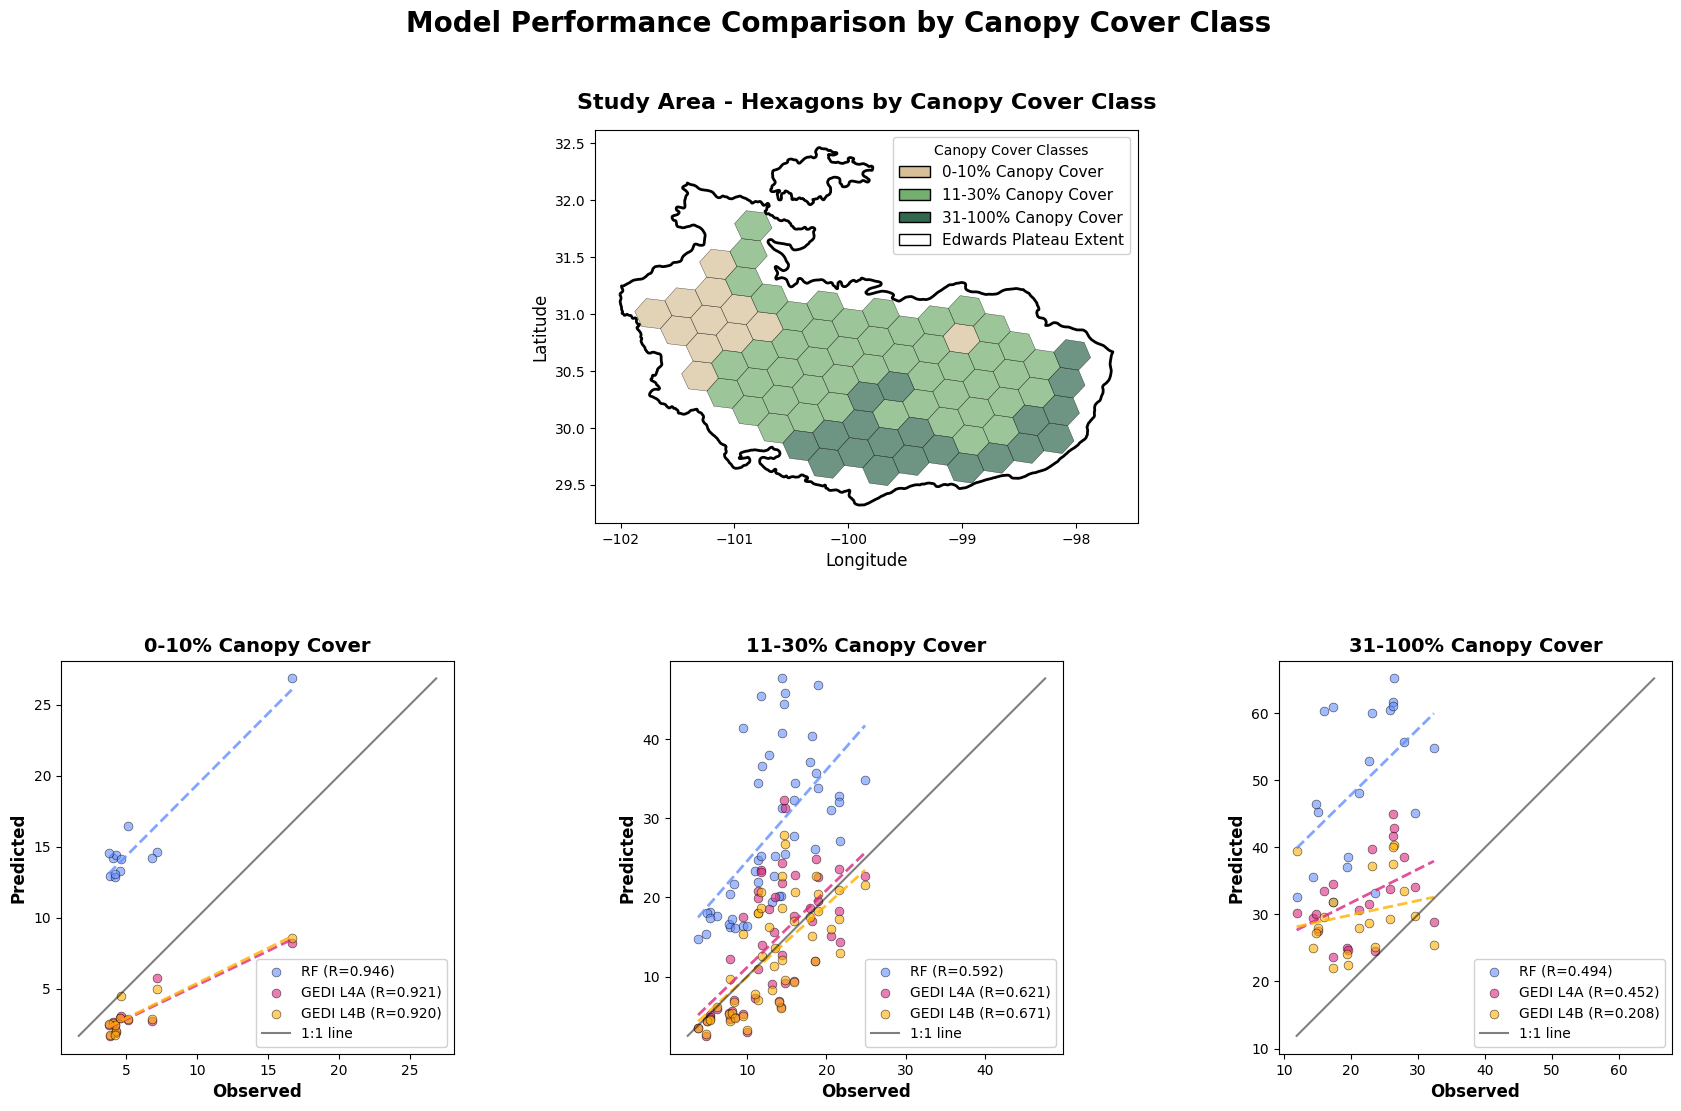


Model Performance Summary by Canopy Class

0-10% Canopy Cover
--------------------------------------------------------------------------------
Model                Pearson R    P-value      RMSE         MAE          N       
--------------------------------------------------------------------------------
RF                   0.9460       0.0000       9.4018       9.3267       12      
GEDI L4A             0.9212       0.0000       3.2164       2.5819       12      
GEDI L4B             0.9195       0.0000       3.1354       2.5042       12      


11-30% Canopy Cover
--------------------------------------------------------------------------------
Model                Pearson R    P-value      RMSE         MAE          N       
--------------------------------------------------------------------------------
RF                   0.5919       0.0000       16.9922      15.0125      48      
GEDI L4A             0.6208       0.0000       6.3063       4.8864       48      
GEDI L4B         

In [ ]:
# load libraries
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from scipy import stats
import geopandas as gpd

# load the CSV files from GEE
rf_data = pd.read_csv('/content/drive/MyDrive/GEE_Exports/RF_model_predicted_vs_observed_w.csv')
gedi_data = pd.read_csv('/content/drive/MyDrive/GEE_Exports/GEDI_model_predicted_vs_observed_w.csv')
gedi_l4b_data = pd.read_csv('/content/drive/MyDrive/GEE_Exports/GEDI_L4B_model_predicted_vs_observed_w.csv')

# load the canopy cover shapefiles
class1_shp = gpd.read_file('/content/drive/MyDrive/GEE_Exports/canopy_class_1_0-10pct.shp')
class2_shp = gpd.read_file('/content/drive/MyDrive/GEE_Exports/canopy_class_2_11-30pct.shp')
class3_shp = gpd.read_file('/content/drive/MyDrive/GEE_Exports/canopy_class_3_31-100pct.shp')

# load the study area outline
study_area = gpd.read_file('/content/drive/MyDrive/biomass_research/edwards_plateau_extent.geojson')

# define class labels and colors
class_labels = {
    1: '0-10% Canopy Cover',
    2: '11-30% Canopy Cover',
    3: '31-100% Canopy Cover'
}

class_colors = {
    1: '#D7C097',  # beige
    2: '#73AF6F',  # light green
    3: '#31694E'   # dark Green
}

# define model info (name, data, column, color)
models = [
    ('RF', rf_data, 'rf_mean', '#648FFF'),  # blue
    ('GEDI L4A', gedi_data, 'gedi_mean', '#DC267F'),  # pink
    ('GEDI L4B', gedi_l4b_data, 'l4b_mean', '#FFB000')  # gold
]

## ----------- create figure with map on top, three plots on bottom --------------
fig = plt.figure(figsize=(22, 12))
gs = fig.add_gridspec(2, 3, hspace=0.35, wspace=0.25, height_ratios=[1, 1])

fig.suptitle('Model Performance Comparison by Canopy Cover Class',
             fontsize=20, fontweight='bold', y=0.98)

# top row: map spanning all three columns
ax_map = fig.add_subplot(gs[0, :])

# plot the study area outline first (as background)
study_area.boundary.plot(ax=ax_map, color='black', linewidth=2,
                         label='Edwards Plateau Extent')

# plot each canopy class
class1_shp.plot(ax=ax_map, color=class_colors[1], edgecolor='black',
                linewidth=0.3, alpha=0.7, label=class_labels[1])
class2_shp.plot(ax=ax_map, color=class_colors[2], edgecolor='black',
                linewidth=0.3, alpha=0.7, label=class_labels[2])
class3_shp.plot(ax=ax_map, color=class_colors[3], edgecolor='black',
                linewidth=0.3, alpha=0.7, label=class_labels[3])

ax_map.set_title('Study Area - Hexagons by Canopy Cover Class',
                 fontsize=16, fontweight='bold', pad=15)
ax_map.set_xlabel('Longitude', fontsize=12)
ax_map.set_ylabel('Latitude', fontsize=12)
ax_map.set_aspect('equal')

# create custom legend handles for canopy classes
legend_handles = [
    mpatches.Patch(facecolor=class_colors[1], edgecolor='black',
                   label=class_labels[1]),
    mpatches.Patch(facecolor=class_colors[2], edgecolor='black',
                   label=class_labels[2]),
    mpatches.Patch(facecolor=class_colors[3], edgecolor='black',
                   label=class_labels[3]),
    mpatches.Patch(facecolor='none', edgecolor='black',
                   label='Edwards Plateau Extent')
]

# add the legend to the map axis
ax_map.legend(handles=legend_handles,
              title='Canopy Cover Classes',
              loc='upper right', fontsize=11, framealpha=0.9)


# bottom row: three comparison plots
axes_plots = [fig.add_subplot(gs[1, i]) for i in range(3)]

for idx, canopy_class in enumerate([1, 2, 3]):
    ax = axes_plots[idx]

    # track min/max values for 1:1 line
    all_min = float('inf')
    all_max = float('-inf')

    # plot each model on the same axes
    for model_name, data, predicted_col, color in models:
        # filter data for this class
        class_data = data[data['canopy_class'] == canopy_class].dropna()

        if len(class_data) > 0:
            predicted = class_data[predicted_col]
            observed = class_data['CRM_LIVE']

            # calculate Pearson correlation
            r, p_value = stats.pearsonr(predicted, observed)

            # update min/max for 1:1 line
            all_min = min(all_min, observed.min(), predicted.min())
            all_max = max(all_max, observed.max(), predicted.max())

            # scatter plot
            ax.scatter(observed, predicted, alpha=0.6, s=40,
                      color=color, edgecolors='black', linewidth=0.5,
                      label=f'{model_name} (R={r:.3f})')

            # line of best fit
            z = np.polyfit(observed, predicted, 1)
            p = np.poly1d(z)
            x_line = np.linspace(observed.min(), observed.max(), 100)
            ax.plot(x_line, p(x_line), color=color, linestyle='--',
                   linewidth=2, alpha=0.8)

    # add 1:1 line
    if all_min != float('inf'):
        ax.plot([all_min, all_max], [all_min, all_max], 'k-',
               linewidth=1.5, alpha=0.5, label='1:1 line')

    # labels and title
    ax.set_xlabel('Observed', fontsize=12, fontweight='bold')
    ax.set_ylabel('Predicted', fontsize=12, fontweight='bold')
    ax.set_title(f'{class_labels[canopy_class]}', fontsize=14, fontweight='bold')
    ax.legend(loc='best', fontsize=10, framealpha=0.9)
   # ax.grid(True, alpha=0.3)

    # equal aspect ratio for better comparison
    ax.set_aspect('equal', adjustable='box')

plt.tight_layout()
plt.show()

# print comprehensive summary stats
print(f"\n{'='*80}")
print(f"Model Performance Summary by Canopy Class")
print(f"{'='*80}")

for canopy_class in [1, 2, 3]:
    print(f"\n{class_labels[canopy_class]}")
    print(f"{'-'*80}")
    print(f"{'Model':<20} {'Pearson R':<12} {'P-value':<12} {'RMSE':<12} {'MAE':<12} {'N':<8}")
    print(f"{'-'*80}")

    for model_name, data, predicted_col, color in models:
        class_data = data[data['canopy_class'] == canopy_class].dropna()

        if len(class_data) > 0:
            predicted = class_data[predicted_col]
            observed = class_data['CRM_LIVE']
            r, p_value = stats.pearsonr(predicted, observed)
            rmse = np.sqrt(np.mean((predicted - observed)**2))
            mae = np.mean(np.abs(predicted - observed))

            print(f"{model_name:<20} {r:<12.4f} {p_value:<12.4f} {rmse:<12.4f} {mae:<12.4f} {len(class_data):<8}")
        else:
            print(f"{model_name:<20} {'No data':<12}")

    print()

## calculate global morans i

Raster shape: (11617, 13785) (rows, cols)
CRS: EPSG:32614
Resolution: (30.0, 30.0)
Valid sample points: 5000

Descriptive statistics:
count    5000.000000
mean       15.334808
std         6.718465
min         5.615092
25%        10.483778
50%        12.106475
75%        19.657277
max        41.842917
Name: value, dtype: float64


/usr/local/lib/python3.12/dist-packages/libpysal/weights/distance.py:153: UserWarning: The weights matrix is not fully connected: 
 There are 2 disconnected components.
  W.__init__(self, neighbors, id_order=ids, **kwargs)


Neighbors per point (KNN): 16

GLOBAL MORAN'S I RESULTS
Moran's I:               0.9839
Expected I:              -0.0002
Variance (normal):       0.000023
Z-score (normal):        205.0017
P-value (normal):        0.0000
P-value (permutation):   0.0010

Interpretation (based on p_sim): SIGNIFICANT POSITIVE spatial autocorrelation (clustering)


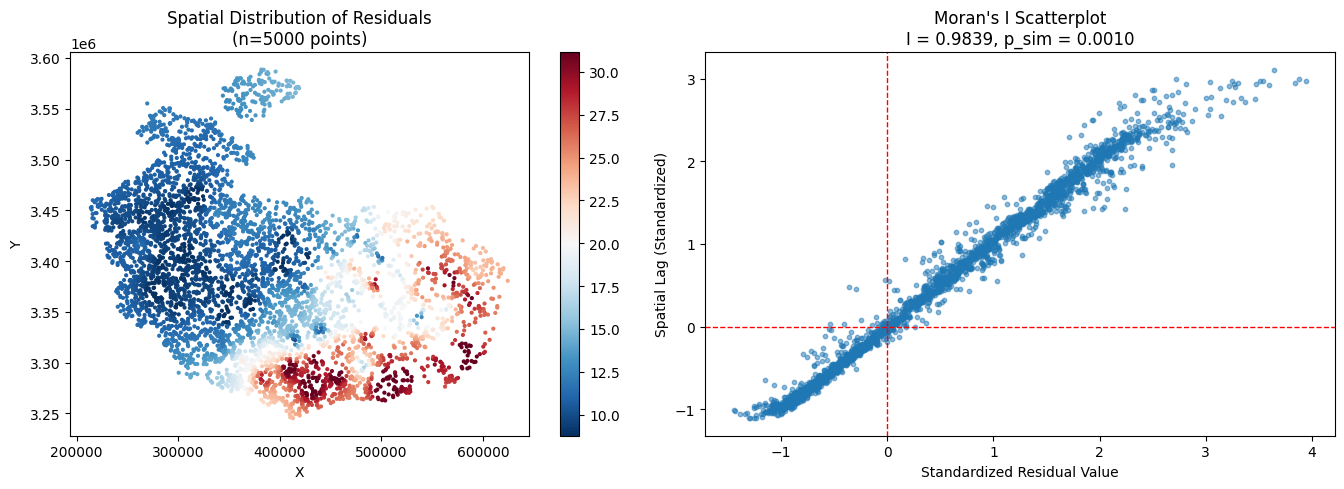

In [ ]:
# global moran's i calculation
# load libraries
#!pip install rasterio geopandas libpysal esda -q
import numpy as np
import rasterio
from rasterio.windows import Window
import geopandas as gpd
from shapely.geometry import Point
from libpysal.weights import DistanceBand, KNN
from esda.moran import Moran
import matplotlib.pyplot as plt

## ------- define parameters --------------
raster_path = '/content/drive/MyDrive/GEE_Exports/rf_residuals_toMoransI_w.tif'

# sampling strategy to manage memory:
# 'random'    -> random sample from full raster
# 'regular'   -> every Nth pixel in both row and column
# 'all'       -> read entire raster (only for small rasters)
# 'block_random' -> true memory-safe sampling using block windows
sampling_strategy = 'random'
sample_size = 5000       # number of pixels to sample for 'random' or 'block_random'
skip_pixels = 5          # stride for 'regular'

# spatial weights configuration
weights_type = 'knn'     # Options: 'knn' or 'distance'
k_neighbors = 16          # typical raster-like neighbor count (Queen ~8)
distance_threshold = 500 # meters, only used if weight_type == 'distance'
distance_style = 'binary' # 'binary' or 'inverse' (if 'distance' weights)

# islands handling (points with no neighbors under distance weights)
drop_islands = True      # drop islands if any; set False to keep

# Moran's I permutations
n_permutations = 999

# Random seed for reproducibility
rng_seed = 42

# ----------- define helper functions -------------------

def choose_utm_crs(geom_series: gpd.GeoSeries):
    """
    choose a suitable UTM CRS (EPSG) based on the mean lon/lat of the geometry and
    returns an EPSG integer
    """
    # ensure in geographic degrees
    if not geom_series.crs or not geom_series.crs.is_geographic:
        tmp = geom_series.to_crs(epsg=4326)
    else:
        tmp = geom_series

    # use centroid of all points for zone selection
    centroid = tmp.unary_union.centroid
    lon, lat = centroid.x, centroid.y

    zone = int(np.floor((lon + 180) / 6) + 1)
    if lat >= 0:
        epsg = 32600 + zone  # WGS84 / UTM Northern Hemisphere
    else:
        epsg = 32700 + zone  # WGS84 / UTM Southern Hemisphere
    return epsg

# load and sample raster

def load_raster_sample(raster_path, strategy='regular', sample_size=5000, skip=5, seed=42):
    """
    load raster with memory-efficient sampling strategies and
    returns a gdf with sampled points and 'value' attribute
    """
    rng = np.random.default_rng(seed)
    with rasterio.open(raster_path) as src:
        print(f"Raster shape: {src.shape} (rows, cols)")
        print(f"CRS: {src.crs}")
        print(f"Resolution: {src.res}")

        transform = src.transform
        crs = src.crs

        if strategy in ('random', 'regular', 'all'):
            # read band with nodata handling (masked -> fill with NaN)
            band = src.read(1, masked=True)
            data = np.ma.filled(band, np.nan)

        if strategy == 'all':
            rows, cols = np.where(~np.isnan(data))
            values = data[rows, cols]

        elif strategy == 'regular':
            rows = np.arange(0, data.shape[0], skip)
            cols = np.arange(0, data.shape[1], skip)
            row_grid, col_grid = np.meshgrid(rows, cols, indexing='ij')
            row_grid = row_grid.flatten()
            col_grid = col_grid.flatten()
            values = data[row_grid, col_grid]
            rows, cols = row_grid, col_grid

        elif strategy == 'random':
            valid_mask = ~np.isnan(data)
            valid_indices = np.argwhere(valid_mask)

            if len(valid_indices) > sample_size:
                sample_indices = rng.choice(len(valid_indices), size=sample_size, replace=False)
                sampled = valid_indices[sample_indices]
                rows, cols = sampled[:, 0], sampled[:, 1]
            else:
                rows, cols = valid_indices[:, 0], valid_indices[:, 1]

            values = data[rows, cols]

        elif strategy == 'block_random':
            # iterate block windows and sample a few per block
            pts = []
            vals = []
            for (idx, window) in src.block_windows(1):
                block = src.read(1, window=window, masked=True)
                block = np.ma.filled(block, np.nan)
                valid = ~np.isnan(block)
                if not valid.any():
                    continue

                r_idx, c_idx = np.where(valid)
                n = len(r_idx)
                take = min(n, max(1, sample_size // 20))  # sample a few per block
                choose = rng.choice(n, size=take, replace=False)
                r_sel, c_sel = r_idx[choose], c_idx[choose]

                # map window coords -> full raster coords
                rows_win = r_sel + window.row_off
                cols_win = c_sel + window.col_off

                xs, ys = rasterio.transform.xy(transform, rows_win, cols_win)
                pts.extend([Point(x, y) for x, y in zip(xs, ys)])
                vals.extend(block[r_sel, c_sel])

                if len(vals) >= sample_size:
                    break

            gdf = gpd.GeoDataFrame({'value': np.array(vals)}, geometry=pts, crs=crs)
            print(f"Valid sample points: {len(gdf)} (block_random)")
            return gdf

        else:
            raise ValueError(f"Unknown sampling strategy: {strategy}")

        # remove any residual NaNs
        valid_mask = ~np.isnan(values)
        rows, cols, values = rows[valid_mask], cols[valid_mask], values[valid_mask]

        print(f"Valid sample points: {len(values)}")

        xs, ys = rasterio.transform.xy(transform, rows, cols)
        geometry = [Point(x, y) for x, y in zip(xs, ys)]
        gdf = gpd.GeoDataFrame({'value': values}, geometry=geometry, crs=crs)
        return gdf

# load the data
gdf = load_raster_sample(
    raster_path,
    strategy=sampling_strategy,
    sample_size=sample_size,
    skip=skip_pixels,
    seed=rng_seed
)

print("\nDescriptive statistics:")
print(gdf['value'].describe())

# create spatial weights matrix

# coordinates in the current CRS
coords = np.column_stack([gdf.geometry.x, gdf.geometry.y])

if weights_type == 'distance':
    # ensure metric CRS (meters) for distance threshold
    if gdf.crs is None:
        raise ValueError("Raster CRS is none. A projected CRS in meters is required for distance weights.")

    is_geographic = False
    try:
        is_geographic = gdf.crs.is_geographic
    except Exception:
        pass

    if is_geographic:
        utm_epsg = choose_utm_crs(gdf.geometry)
        print(f"Reprojecting to metric CRS: EPSG:{utm_epsg} (UTM)")
        gdf = gdf.to_crs(epsg=utm_epsg)
        coords = np.column_stack([gdf.geometry.x, gdf.geometry.y])

    # build DistanceBand weights
    # start with binary connectivity; optionally convert to inverse-distance below
    w = DistanceBand(coords, threshold=distance_threshold, binary=True, silence_warnings=True)

    # handle islands (areas with no neighbors)
    if getattr(w, 'islands', []):
        print(f"Found {len(w.islands)} islands (no neighbors) at threshold={distance_threshold}")
        if drop_islands:
            keep_inds = np.setdiff1d(np.arange(len(coords)), w.islands)
            w = w.subset(keep_inds)
            gdf = gdf.iloc[keep_inds].reset_index(drop=True)
            coords = coords[keep_inds]
            print(f"Dropped islands; remaining points: {len(gdf)}")
        else:
            print("Consider increasing DISTANCE_THRESHOLD or enable DROP_ISLANDS=True")

    # optional: inverse-distance weights
    if distance_style == 'inverse':
        Wij = w.sparse.copy()
        # avoid division by zero (no zero distances should exist except self; DistanceBand excludes self)
        Wij.data = 1.0 / Wij.data
        w.sparse = Wij

    # row-standardize weights
    w.transform = 'r'

    avg_neighbors = np.mean(list(w.cardinalities.values()))
    print(f"Average neighbors per point: {avg_neighbors:.1f}")

elif weights_type == 'knn':
    w = KNN(coords, k=k_neighbors)
    w.transform = 'r'
    print(f"Neighbors per point (KNN): {k_neighbors}")

else:
    raise ValueError(f"Unknown WEIGHTS_TYPE: {weights_type}")

# ------------ calculate global moran's i -----------------------

y = gdf['value'].values
moran = Moran(y, w, permutations=n_permutations)

# print results
print("\n" + "="*60)
print("GLOBAL MORAN'S I RESULTS")
print("="*60)
print(f"Moran's I:               {moran.I:.4f}")
print(f"Expected I:              {moran.EI:.4f}")
print(f"Variance (normal):       {moran.VI_norm:.6f}")
print(f"Z-score (normal):        {moran.z_norm:.4f}")
print(f"P-value (normal):        {moran.p_norm:.4f}")
print(f"P-value (permutation):   {moran.p_sim:.4f}")
print("="*60)

# permutation p-value for inference
if moran.p_sim < 0.05:
    interpretation = ("SIGNIFICANT POSITIVE spatial autocorrelation (clustering)"
                      if moran.I > 0 else
                      "SIGNIFICANT NEGATIVE spatial autocorrelation (dispersion)")
else:
    interpretation = "NO significant spatial autocorrelation (random pattern)"
print(f"\nInterpretation (based on p_sim): {interpretation}")

# -------- visualization -------------------

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# spatial distribution of residuals
markersize = 4 if len(gdf) <= 10000 else 2
gdf.plot(
    column='value',
    cmap='RdBu_r',
    legend=True,
    ax=ax1,
    markersize=markersize,
    vmin=gdf['value'].quantile(0.02),
    vmax=gdf['value'].quantile(0.98)
)
ax1.set_title(f'Spatial Distribution of Residuals\n(n={len(gdf)} points)')
ax1.set_xlabel('X'); ax1.set_ylabel('Y')

# moran scatterplot
lag = w.sparse.dot(y)
y_std = y.std(ddof=0)
lag_std = lag.std(ddof=0)

if np.isclose(y_std, 0) or np.isclose(lag_std, 0):
    ax2.text(0.5, 0.5, "Near-zero variance; scatter unavailable.", ha='center')
else:
    standardized_values = (y - y.mean()) / y_std
    standardized_lag = (lag - lag.mean()) / lag_std
    ax2.scatter(standardized_values, standardized_lag, alpha=0.5, s=10)
    ax2.axhline(0, color='red', linestyle='--', linewidth=1)
    ax2.axvline(0, color='red', linestyle='--', linewidth=1)
    ax2.set_xlabel('Standardized Residual Value')
    ax2.set_ylabel('Spatial Lag (Standardized)')
    ax2.set_title(f"Moran's I Scatterplot\nI = {moran.I:.4f}, p_sim = {moran.p_sim:.4f}")

plt.tight_layout()
plt.savefig('morans_i_results.png', dpi=300, bbox_inches='tight')
plt.show()

## getis-ord * analysis

/usr/local/lib/python3.12/dist-packages/libpysal/weights/distance.py:153: UserWarning: The weights matrix is not fully connected: 
 There are 2 disconnected components.
  W.__init__(self, neighbors, id_order=ids, **kwargs)


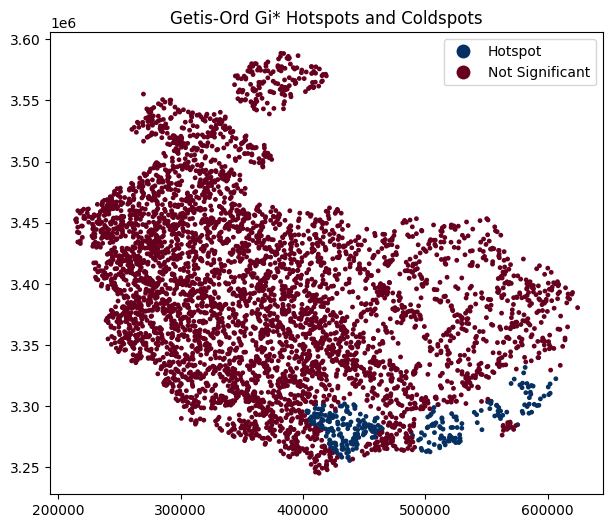


Getis-Ord Gi* summary:
Gi_category
Not Significant    4704
Hotspot             296
Name: count, dtype: int64

Interpretation: Hotspots detected; no coldspots.


In [ ]:
# load getis ord *
from esda.getisord import G_Local

# ensure coords and vals are from current gdf
coords = np.column_stack([gdf.geometry.x, gdf.geometry.y])
vals = gdf['value'].values

# create spatial weights (KNN)
w_gi = KNN(coords, k=16)
w_gi.transform = 'r'

# compute Gi* statistic
gi_star = G_Local(vals, w_gi)

# add Gi* z-scores to existing gdf
gdf['GiZ'] = gi_star.Zs

# classify hotspots/coldspots (95% confidence)
gdf['Gi_category'] = np.where(gdf['GiZ'] > 1.96, 'Hotspot',
                        np.where(gdf['GiZ'] < -1.96, 'Coldspot', 'Not Significant'))

# plot results
fig, ax = plt.subplots(figsize=(8, 6))
gdf.plot(column='Gi_category', categorical=True, legend=True,
         cmap='RdBu_r', ax=ax, markersize=6)
ax.set_title('Getis-Ord Gi* Hotspots and Coldspots')
plt.show()

# print summary and interpretation
print("\nGetis-Ord Gi* summary:")
print(gdf['Gi_category'].value_counts())

if 'Coldspot' in gdf['Gi_category'].values:
    print("\nInterpretation: Both hotspots and coldspots detected.")
elif 'Hotspot' in gdf['Gi_category'].values:
    print("\nInterpretation: Hotspots detected; no coldspots.")
else:
    print("\nInterpretation: No significant hotspots or coldspots.")

## Updated uncertainty analysis

Total hexagons: 80
       FIA_observed  mean_predicted  mean_ensemble_sd  absolute_error  \
count     80.000000       80.000000         80.000000       80.000000   
mean      14.093879       29.889824         11.284966       15.795944   
std        7.097399       13.365259          4.567790        8.782070   
min        3.776041       12.814904          5.797424        4.075546   
25%        8.046143       17.696027          6.693645        9.056637   
50%       14.317477       29.006529         10.974773       12.447405   
75%       18.737219       37.490089         14.574624       20.839050   
max       32.370353       61.428501         20.224656       41.747659   

       hexagon_rmse    pixel_count  
count     80.000000      80.000000  
mean      21.678811  685845.375000  
std       11.332108   46740.071176  
min        8.308234  505629.000000  
25%       11.580462  684225.500000  
50%       17.613219  704980.000000  
75%       30.580768  712861.500000  
max       50.488894  718687

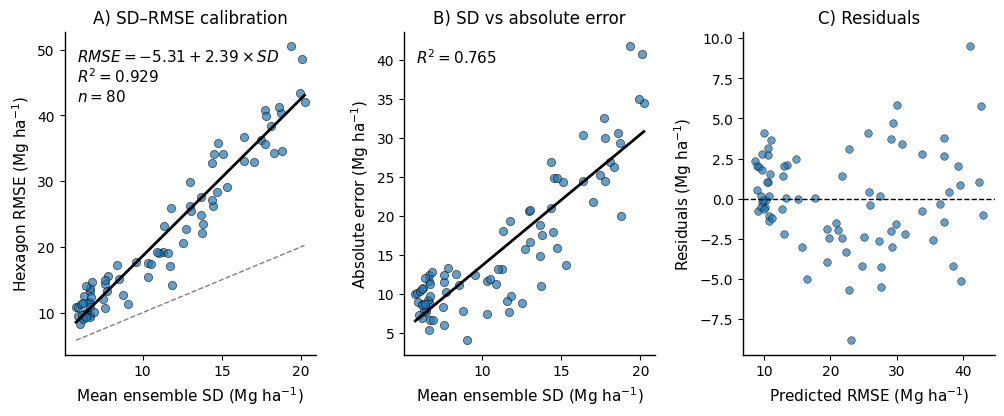


KEY DIAGNOSTIC: SD vs RMSE Comparison
Mean Ensemble SD: 11.28 Mg/ha
Mean Actual RMSE: 21.68 Mg/ha
Underestimation Ratio (RMSE/SD): 1.92

⚠️ FINDING: SD underestimates actual error by factor of 1.92
   The ensemble SD map is OVERCONFIDENT and requires calibration.

CALIBRATION COEFFICIENTS FOR GEE
var interceptA = -5.3058791742636355;
var slopeB = 2.3912070502029534;
// R-squared = 0.9290

Coefficients saved to 'calibration_coefficients.csv'


In [ ]:
# ==================================================================================
# GOOGLE COLAB: SD vs RMSE Calibration Analysis
# Run this after exporting 'hexagon_sd_rmse_calibration_data.csv' from GEE
# ==================================================================================

# Install required packages
!pip install scipy statsmodels -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy import stats
import statsmodels.api as sm
from google.colab import drive

# preset plotting parameters
mpl.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size': 11,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'axes.linewidth': 1.0,
    'axes.spines.top': False,
    'axes.spines.right': False
})


# Load the exported calibration data
data_path = '/content/drive/MyDrive/GEE_Exports/hexagon_sd_rmse_calibration_data_weighted.csv'
df = pd.read_csv(data_path)

# Display basic info
print(f"Total hexagons: {len(df)}")
print(df.describe())

# ==================================================================================
# STEP 2: Linear Regression - SD vs RMSE Calibration
# ==================================================================================

# Extract variables
X = df['mean_ensemble_sd'].values  # σ̄_h
y_rmse = df['hexagon_rmse'].values  # RMSE_h
y_abs_error = df['absolute_error'].values  # |ε_h|

# Remove any NaN values
mask = ~(np.isnan(X) | np.isnan(y_rmse))
X_clean = X[mask]
y_rmse_clean = y_rmse[mask]
y_abs_clean = y_abs_error[mask]

print(f"Valid hexagons after cleaning: {len(X_clean)}")

# ----- Fit Linear Model: RMSE = a + b * SD -----
X_with_const = sm.add_constant(X_clean)
model_rmse = sm.OLS(y_rmse_clean, X_with_const).fit()

print("\n" + "="*60)
print("LINEAR REGRESSION RESULTS: SD → RMSE")
print("="*60)
print(model_rmse.summary())

# Extract coefficients
intercept_a = model_rmse.params[0]
slope_b = model_rmse.params[1]
r_squared = model_rmse.rsquared

print(f"\nCalibration Model: Expected_Error = {intercept_a:.4f} + {slope_b:.4f} * SD")
print(f"R-squared: {r_squared:.4f}")

# ----- Also fit for Absolute Error -----
model_abs = sm.OLS(y_abs_clean, X_with_const).fit()
print("\n" + "="*60)
print("LINEAR REGRESSION RESULTS: SD → Absolute Error")
print("="*60)
print(f"R-squared: {model_abs.rsquared:.4f}")

# ==================================================================================
# DIAGNOSTIC PLOTS
# ==================================================================================

# ==================================================================================
# PUBLICATION-READY FIGURES (SCATTER VERSION – ~80 POINTS)
# ==================================================================================

fig = plt.figure(figsize=(12, 4.2))
gs = fig.add_gridspec(1, 3, wspace=0.35)

x_line = np.linspace(X_clean.min(), X_clean.max(), 200)

# ------------------------------------------------------------------------------
# Panel A: SD vs RMSE (Main calibration)
# ------------------------------------------------------------------------------
ax1 = fig.add_subplot(gs[0, 0])

ax1.scatter(
    X_clean,
    y_rmse_clean,
    s=35,
    alpha=0.7,
    facecolor='tab:blue',
    edgecolor='black',
    linewidth=0.5
)

ax1.plot(
    x_line,
    intercept_a + slope_b * x_line,
    color='black',
    lw=2,
    label='Calibration fit'
)

ax1.plot(
    x_line,
    x_line,
    linestyle='--',
    color='gray',
    lw=1,
    label='1:1 line'
)

ax1.set_xlabel('Mean ensemble SD (Mg ha$^{-1}$)')
ax1.set_ylabel('Hexagon RMSE (Mg ha$^{-1}$)')
ax1.set_title('A) SD–RMSE calibration')

ax1.text(
    0.05, 0.95,
    f'$RMSE = {intercept_a:.2f} + {slope_b:.2f} \\times SD$\n'
    f'$R^2 = {r_squared:.3f}$\n'
    f'$n = {len(X_clean)}$',
    transform=ax1.transAxes,
    va='top'
)

# ------------------------------------------------------------------------------
# Panel B: SD vs Absolute Error
# ------------------------------------------------------------------------------
ax2 = fig.add_subplot(gs[0, 1])

ax2.scatter(
    X_clean,
    y_abs_clean,
    s=35,
    alpha=0.7,
    facecolor='tab:blue',
    edgecolor='black',
    linewidth=0.5
)

ax2.plot(
    x_line,
    model_abs.params[0] + model_abs.params[1] * x_line,
    color='black',
    lw=2
)

ax2.set_xlabel('Mean ensemble SD (Mg ha$^{-1}$)')
ax2.set_ylabel('Absolute error (Mg ha$^{-1}$)')
ax2.set_title('B) SD vs absolute error')

ax2.text(
    0.05, 0.95,
    f'$R^2 = {model_abs.rsquared:.3f}$',
    transform=ax2.transAxes,
    va='top'
)

# ------------------------------------------------------------------------------
# Panel C: Residual diagnostics
# ------------------------------------------------------------------------------
ax3 = fig.add_subplot(gs[0, 2])

residuals = y_rmse_clean - model_rmse.predict(X_with_const)

ax3.scatter(
    model_rmse.predict(X_with_const),
    residuals,
    s=30,
    alpha=0.7,
    facecolor='tab:blue',
    edgecolor='black',
    linewidth=0.4
)

ax3.axhline(0, color='black', linestyle='--', lw=1)

ax3.set_xlabel('Predicted RMSE (Mg ha$^{-1}$)')
ax3.set_ylabel('Residuals (Mg ha$^{-1}$)')
ax3.set_title('C) Residuals')

# ------------------------------------------------------------------------------
# Save outputs
# ------------------------------------------------------------------------------
plt.savefig(
    '/content/drive/MyDrive/GEE_Exports/sd_rmse_calibration_publication.pdf',
    bbox_inches='tight'
)
plt.savefig(
    '/content/drive/MyDrive/GEE_Exports/sd_rmse_calibration_publication.png',
    dpi=600,
    bbox_inches='tight'
)

plt.show()


# ==================================================================================
# KEY DIAGNOSTIC: Does SD underestimate RMSE?
# ==================================================================================

print("\n" + "="*60)
print("KEY DIAGNOSTIC: SD vs RMSE Comparison")
print("="*60)

mean_sd = np.mean(X_clean)
mean_rmse = np.mean(y_rmse_clean)
underestimation_ratio = mean_rmse / mean_sd

print(f"Mean Ensemble SD: {mean_sd:.2f} Mg/ha")
print(f"Mean Actual RMSE: {mean_rmse:.2f} Mg/ha")
print(f"Underestimation Ratio (RMSE/SD): {underestimation_ratio:.2f}")

if underestimation_ratio > 1:
    print("\n⚠️ FINDING: SD underestimates actual error by factor of {:.2f}".format(underestimation_ratio))
    print("   The ensemble SD map is OVERCONFIDENT and requires calibration.")
else:
    print("\n✓ SD provides reasonable uncertainty estimates")

# ==================================================================================
# SAVE CALIBRATION COEFFICIENTS FOR GEE
# ==================================================================================

print("\n" + "="*60)
print("CALIBRATION COEFFICIENTS FOR GEE")
print("="*60)
print(f"var interceptA = {intercept_a};")
print(f"var slopeB = {slope_b};")
print(f"// R-squared = {r_squared:.4f}")

# Save coefficients to file
coefficients = {
    'intercept_a': intercept_a,
    'slope_b': slope_b,
    'r_squared': r_squared,
    'n_hexagons': len(X_clean)
}

pd.DataFrame([coefficients]).to_csv(
    '/content/drive/MyDrive/GEE_Exports/calibration_coefficients.csv',
    index=False
)
print("\nCoefficients saved to 'calibration_coefficients.csv'")